<details>
<summary>

# 📘 proto2_denit_modificadoV2_doc

</summary>

Este notebook documenta el procedimiento de simulación acoplada entre flujo, transporte y reacciones geoquímicas.

<details>
<summary><b>Objetivo</b></summary>

Se describe cada bloque del notebook para facilitar la comprensión del algoritmo y del flujo general de la simulación.

</details>

<details>
<summary><b>Secuencia de ejecución</b></summary>

Se cargan las librerías y parámetros, se ejecuta el ciclo acoplado GWF–GWT–REMIX y se actualizan las concentraciones en cada paso de tiempo.

</details>

<details>
<summary><b>Intercambio con REMIX</b></summary>

Los componentes transportados se escriben en `u_tilde.dat`; posteriormente REMIX genera `u_new.out`, cuyas concentraciones se utilizan como condiciones iniciales del siguiente paso.

</details>

<details>
<summary><b>Comparación de resultados</b></summary>

En los pasos `NT = 1`, `2`, `10` y `100` se comparan gráficamente los resultados numéricos con los datos de referencia contenidos en `DENIT-10.xlsx`.

</details>

<details>
<summary><b>Visualización</b></summary>

Al finalizar la simulación se presentan las gráficas correspondientes al flujo, los componentes iniciales, los componentes actualizados y las especies químicas obtenidas.

</details>

<details>
<summary><b>Documentación</b></summary>

La documentación fue incorporada antes de cada bloque, manteniendo intacto el contenido de todas las celdas de código.

</details>

</details>

<details>
<summary>

## BLOQUE 1. Librerías

</summary>

Esta celda importa las bibliotecas necesarias para ejecutar el modelo acoplado y define un separador visual para la salida en pantalla.

<details>
<summary><b>Librerías</b></summary>

Se importan los módulos `os`, `numpy`, `matplotlib.pyplot`, `pandas`, `xmf6` y los paquetes `gwf`, `gwt`, `plot` y `utils` del proyecto `denit`.

</details>

<details>
<summary><b>Línea separadora</b></summary>

Se define la variable `linea`, utilizada como separador visual en la salida de pantalla.

</details>

</details>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xmf6
from denit import gwf, gwt, plot, utils
linea = 50*chr(0x2015)

<details>
<summary>

## BLOQUE 2. Rutas, condiciones iniciales, datos de comparación y parámetros del modelo

</summary>

Configuración del experimento numérico, definiendo los archivos, parámetros y datos necesarios para ejecutar la simulación acoplada.

<details>
<summary><b>Rutas</b></summary>

Se definen las rutas de trabajo, los archivos de intercambio con REMIX y los comandos necesarios para ejecutar el modelo.

</details>

<details>
<summary><b>Condiciones iniciales</b></summary>

Se cargan las concentraciones iniciales de componentes y especies, además del número de componentes químicos del sistema.

</details>

<details>
<summary><b>Simulación</b></summary>

Se establecen el paso de tiempo `dt` y el número de iteraciones externas `NT` del proceso acoplado.

</details>

<details>
<summary><b>Comparación con Excel</b></summary>

Se leen los datos de referencia de `DENIT-10.xlsx` y se preparan las etiquetas utilizadas en las comparaciones gráficas.

</details>

<details>
<summary><b>Discretización</b></summary>

Se define la malla unidimensional y las dimensiones espaciales empleadas en la simulación.

</details>

<details>
<summary><b>Parámetros físicos</b></summary>

Se agrupan en `phys` las propiedades físicas y las condiciones necesarias para construir los modelos GWF y GWT.

</details>

</details>

In [2]:
#
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\NRBRT\clone\CICLOS-GWF-GWT\CICLO-DENIT5M\mf6\bin\mf6",
    #mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "mf6_gwf_gwt_comp", 
    tran_name = "transport",
    tran_ws = "mf6_gwf_gwt_comp",
    #
    # Nombre de los archivos de datos en remix
    u_init = os.path.join("remix", "u_init.dat"),
    u_tilde = os.path.join("remix", "u_tilde.dat"),
    u_new = os.path.join("remix", "u_new.out"),
    #
    # Ejecutable REMIX y archivo de entrada en remix
    remix_exe = os.path.join("remix", "bin", "interfaz_remix.exe"),
    remix_input = os.path.join("datos_interfaz_denit_2reacts"),
)
paths["command"] = f"{paths["remix_exe"]} < {paths["remix_input"]}"
#
# --- DEFINIENDO CONDICIONES INICIALES ---
#
print(linea)
print("Generating initial conditions".center(50))
components, especies = utils.initial_conditions(paths, comp = True, spec=True)
ncomp = len(components["names"])
#components["init_conc"] = test()
print(linea)
#
xmf6.nice_print(paths, "Paths and filenames")
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Paso del tiempo
dt = 1.0e-2 #días
NT = 1 #repeticiones del ciclo externo

#
# --- DATOS DE COMPARACION DENIT-10.xlsx ---
# Se leen una sola vez antes del ciclo principal.
# Las filas están en numeración de Excel: C:L -> columnas 2:12 en pandas.
df_denit = pd.read_excel(
    r".\remix\DENIT-10.xlsx",
    header=None
)

filas_excel_denit = {
    1: 351,
    2: 366,
    10: 381,
    100: 396,
}

# Etiquetas de especies tomadas de u_init.dat, renglones 13-20.
with open(paths["u_init"], "r") as f:
    lineas_u_init = f.readlines()

etiquetas_denit = [
    lineas_u_init[i].strip()
    for i in range(12, 20)
]
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 10
delr, delc, delz = 0.1, 1, 1  #0.1, 1, 1 (dx,dy,dz)
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print(dis, "Spatial discretization")
#
# Parámetros físicos.
phys = dict(
    perioddata = [(dt, 1, 1.0)], #PERLEN, NSTP, TSMULT 
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($m s^{-1}$)
    inflow = 0.2,  # inflow ($m d^{-1}$)
    longitudinal_dispersivity = 1.0, # 1.0? 
    components = components["names"], # Components names
    source_concentration = components["ext_water"],  # Source concentration (unitless)
    initial_concentration = components["init_conc"], # Initial concentration (unitless)
)
xmf6.nice_print(phys, "Physical parameters")

――――――――――――――――――――――――――――――――――――――――――――――――――
          Generating initial conditions           
-> File remix\u_init.dat already exist
――――――――――――――――――――――――――――――――――――――――――――――――――

Paths and filenames
―――――――――――――――――――
    mf6_exe = C:\Users\NRBRT\clone\CICLOS-GWF-GWT\CICLO-DENIT5M\mf6\bin\mf6
  flow_name = flow
    flow_ws = mf6_gwf_gwt_comp
  tran_name = transport
    tran_ws = mf6_gwf_gwt_comp
     u_init = remix\u_init.dat
    u_tilde = remix\u_tilde.dat
      u_new = remix\u_new.out
  remix_exe = remix\bin\interfaz_remix.exe
remix_input = datos_interfaz_denit_2reacts
    command = remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts
―――――――――――――――――――

Spatial discretization
――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 10
        delr = 0.1
        delc = 1
         top = 1
        botm = 0.0
――――――――――――――――――――――

Physical parameters
―――――――――――――――――――
               perioddata = ―― data array ――
           

<details>
<summary>

## BLOQUE 3. Ciclo principal GWF-GWT-REMIX y comparación con Excel

</summary>

Esta celda implementa el ciclo de simulación acoplado entre flujo, transporte y reacciones geoquímicas, además de comparar los resultados obtenidos con datos de referencia.

<details>
<summary><b>Inicialización</b></summary>

Se crea la estructura `u_tilde`, donde se almacenarán temporalmente las concentraciones calculadas para cada componente.

</details>

<details>
<summary><b>Ciclo temporal</b></summary>

Se ejecuta el ciclo principal de simulación, avanzando un paso de tiempo en cada iteración.

</details>

<details>
<summary><b>Componentes</b></summary>

Para cada componente químico se ejecutan secuencialmente los modelos de flujo (GWF) y transporte (GWT), almacenando las concentraciones obtenidas en `u_tilde.dat`.

</details>

<details>
<summary><b>`u_tilde.dat`</b></summary>

Las concentraciones calculadas se escriben en el archivo `u_tilde.dat`, que sirve como entrada para REMIX.

</details>

<details>
<summary><b>REMIX</b></summary>

Se ejecuta REMIX para resolver las reacciones geoquímicas utilizando las concentraciones transportadas.

</details>

<details>
<summary><b>`u_new.out`</b></summary>

Se leen las concentraciones actualizadas generadas por REMIX y se utilizan como condiciones iniciales para el siguiente paso de tiempo.

</details>

<details>
<summary><b>Comparación con Excel</b></summary>

En los pasos `NT = 1`, `2`, `10` y `100`, los resultados obtenidos se comparan gráficamente con los datos de referencia contenidos en `DENIT-10.xlsx`.

</details>

</details>

――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 1, time = 0.01d              
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT: C4 | GWF-GWT: C5 | GWF-GWT: C6 | GWF-GWT: C7 |
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
     Graficas de comparacion DENIT-10, NT = 1     
――――――――――――――――――――――――――――――――――――――――――――――――――


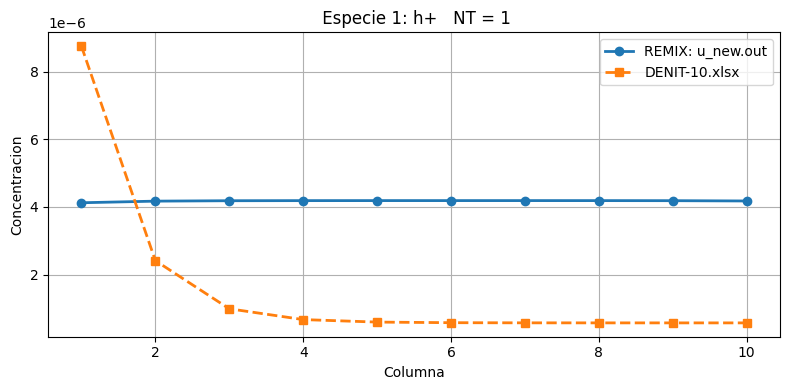

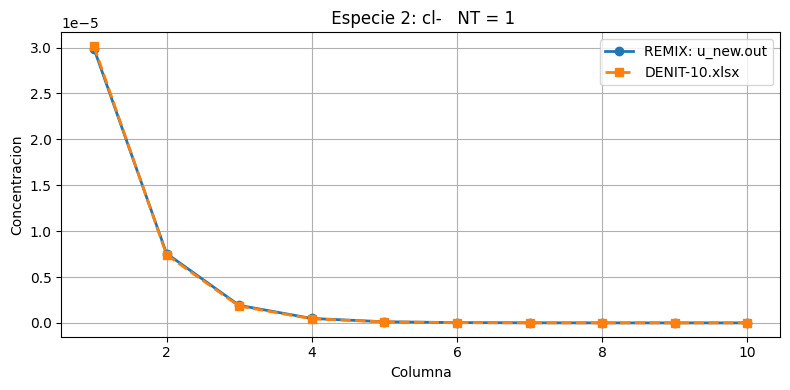

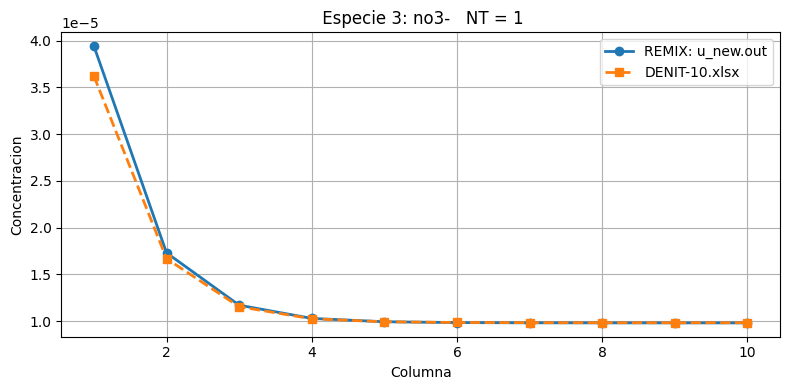

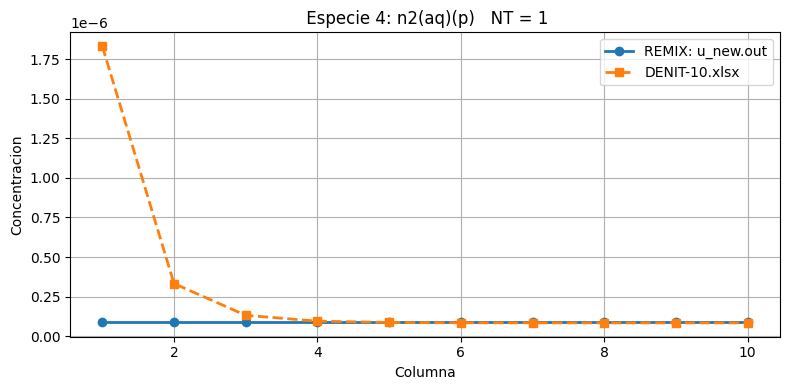

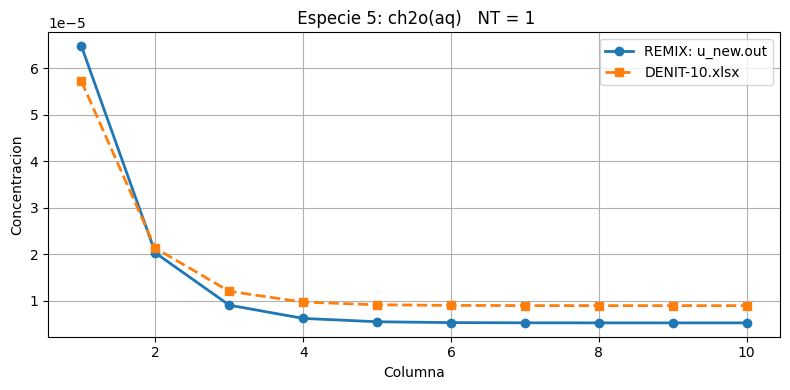

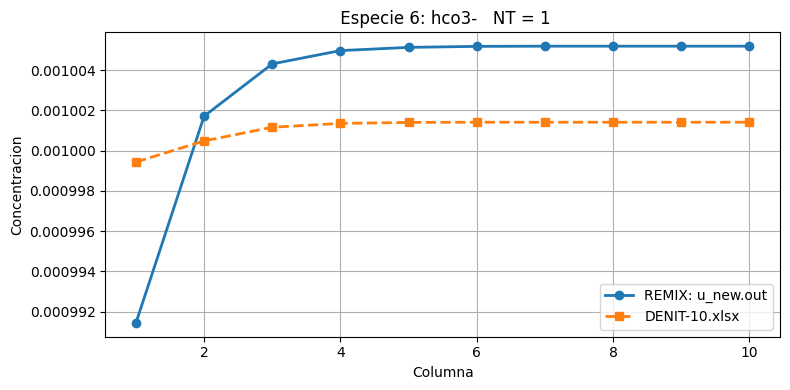

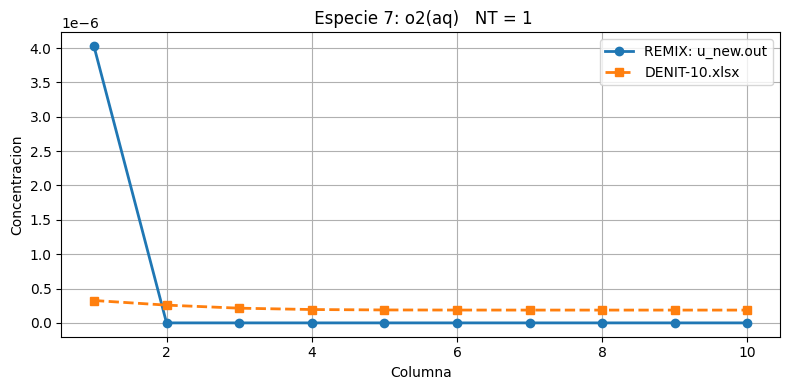

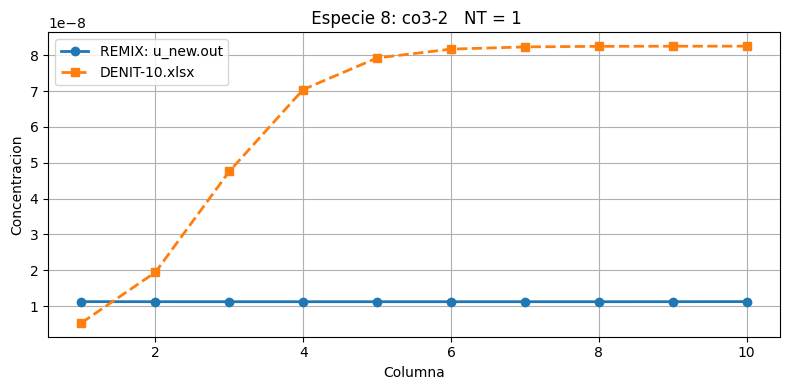

In [3]:
u_tilde = [0 for i in range(0,ncomp)]

for it in range(1, NT+1): #ciclo de tiempo
    print(linea)
    print(f"Step = {it}, time = {it * dt}d".center(50))
    print(linea)

    for m in range(0, ncomp): # ciclo componentes
        #
        # - ACTUALIZACION DEL FLUJO CON GWF ---
        #
        # --- Construcción de la simulación de flujo
        o_sim_f = gwf.build(phys, dis, m, paths) #escribe archivos sim_flujo
        #
        # --- Ejecución de la simulación ---
        print(" GWF", end = "")
        o_sim_f.run_simulation(silent=True)
        #
        # - SIMULACIÓN DE TRANSPORTE CON GWT PARA CADA COMPONENTE
        #
        # --- Construcción de la simulación de transporte
        o_sim_t = gwt.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación de transporte ---
        print(f"-GWT: C{m+1}", end= " |")
        o_sim_t.run_simulation(silent=True) #por componente
        #
        # --- Obtenemos la concentración calculada por GWT
        u_tilde[m] = utils.get_conc(o_sim_t) #guardar en u_tilde por componente
    #
    # --- Guardamos concentraciones en "u_tilde.dat"
    print("\n-> Writting: u_tilde.dat")
    with open(paths["u_tilde"], "w") as f:
        for a in u_tilde: 
            f.writelines(" ".join([c for c in a.astype(str)]))
            f.write("\n")
    #
    # ---- Ejecutamos REMIX usando las nuevas concentraciones
    print(f"-> Executing: {paths["command"]}\n")
    ret = os.system(paths["command"])
    print(f"\n-> Error code: {ret}")
    #
    # --- Leemos las concentraciones de las componentes calculadas por REMIX
    print(f"-> Reading: {paths["u_new"]}")
    with open(paths["u_new"], "r") as f:
        lines = f.readlines()
    #
    # Actualizamos las concentraciones para GWT
    key_string = "Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):"
    iccn = utils.find_index(lines, key_string, 2)
    u_new = [np.array(l.split(), dtype=float) for l in lines[iccn:iccn+ncomp]]
    
    phys["initial_concentration"] = u_new


    #
    # --- GRAFICAS DE COMPARACION u_new.out vs DENIT-10.xlsx ---
    # Se ejecutan dentro del ciclo principal para conservar el u_new
    # correspondiente a los pasos it = 1, 2, 10 y 100.
    #
    if it in filas_excel_denit:
        fila_excel_inicio = filas_excel_denit[it]

        print(linea)
        print(f"Graficas de comparacion DENIT-10, NT = {it}".center(50))
        print(linea)

        for k in range(8):
            # u_new.out: renglones 13-20 en numeracion de archivo.
            renglon_u_new = 13 + k
            datos_u_new = np.array(
                lines[renglon_u_new - 1].split(),
                dtype=float
            )

            # DENIT-10.xlsx: bloques C:L segun NT.
            renglon_excel = fila_excel_inicio + k
            datos_excel = (
                df_denit.iloc[renglon_excel - 1, 2:12]
                .astype(float)
                .to_numpy()
            )

            # Eje X comun.
            n = min(len(datos_u_new), len(datos_excel))
            x_comp = np.arange(1, n + 1)

            etiqueta = etiquetas_denit[k]

            plt.figure(figsize=(8, 4))

            plt.plot(
                x_comp,
                datos_u_new[:n],
                "o-",
                linewidth=2,
                label="REMIX: u_new.out"
            )

            plt.plot(
                x_comp,
                datos_excel[:n],
                "s--",
                linewidth=2,
                label="DENIT-10.xlsx"
            )

            plt.title(f" Especie {etiqueta}   NT = {it}")
            plt.xlabel("Columna")
            plt.ylabel("Concentracion")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
    
   


<details>
<summary>

## BLOQUE 4. Lectura de especies después de REMIX

</summary>

Esta celda recupera las concentraciones de las especies químicas generadas por REMIX para su análisis y representación gráfica.

<details>
<summary><b>Lectura de <code>u_new.out</code></b></summary>

Se localiza en `u_new.out` el bloque correspondiente a las especies de actividad variable.

</details>

<details>
<summary><b>Construcción de <code>s_new</code></b></summary>

Las concentraciones de las especies se almacenan en el arreglo `s_new`, utilizado en las gráficas finales.

</details>

</details>

In [4]:
# --- Leemos las concentraciones de las componentes calculadas por REMIX
print(f"-> Reading: {paths["u_new"]}")
with open(paths["u_new"], "r") as f:
    lines = f.readlines()


# Actualizamos las concentraciones para GWT
key_string = "Concentrations of variable activity species after solving reactive mixing iteration (rows: species, columns: targets):"
iccn = utils.find_index(lines, key_string, 2)
s_new = [np.array(l.split(), dtype=float) for l in lines[iccn:iccn+ncomp+1]]


-> Reading: remix\u_new.out


<details>
<summary>

## BLOQUE 5. Visualización del flujo

</summary>

Representación gráfica de la solución hidráulica obtenida durante la simulación de flujo.

<details>
<summary><b>Lectura del flujo</b></summary>

Se obtienen la carga hidráulica y la información espacial del último modelo GWF ejecutado.

</details>

<details>
<summary><b>Visualización</b></summary>

Se genera la gráfica de la distribución de la carga hidráulica sobre la malla del modelo.

</details>

</details>

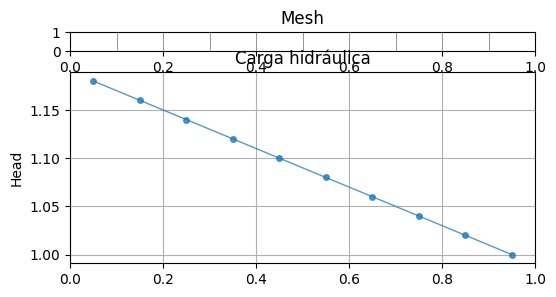

In [5]:
###############################################################
# BLOQUE 5. VISUALIZACION DEL FLUJO
# Recupera la carga hidraulica calculada por GWF.
###############################################################

o_gwf, head, x, y, z = utils.get_head(o_sim_f)
plot.show_f(o_gwf, head, x, y, z, ncol=ncol, delr=delr)

<details>
<summary>

## BLOQUE 6. Componentes iniciales

</summary>

Representación gráfica de las concentraciones iniciales de los componentes químicos definidos en el modelo.

<details>
<summary><b>Datos</b></summary>

Se utilizan las concentraciones iniciales y los nombres de los componentes para construir la gráfica.

</details>

<details>
<summary><b>Visualización</b></summary>

Las concentraciones se muestran en escala logarítmica para facilitar la comparación entre distintos órdenes de magnitud.

</details>

</details>

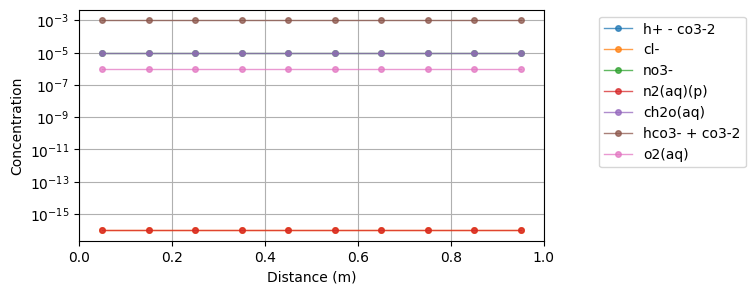

In [6]:
###############################################################
# BLOQUE 6. COMPONENTES INICIALES
# Grafica las concentraciones iniciales.
###############################################################

plot.show_t(components["init_conc"], components["names"], x, y, z, ncol=ncol, delr=delr, yscale="log")

<details>
<summary>

## BLOQUE 7. Impresión de componentes iniciales

</summary>

Esta celda muestra en pantalla las concentraciones iniciales de los componentes químicos del modelo.

<details>
<summary><b>Impresión</b></summary>

Se imprime el arreglo `components["init_conc"]` para verificar los valores iniciales utilizados en la simulación.

</details>

</details>

In [7]:
###############################################################
# BLOQUE 7. IMPRESION DE COMPONENTES INICIALES
###############################################################

print(components["init_conc"])

[array([-3.69029e-07, -3.69029e-07, -3.69029e-07, -3.69029e-07,
       -3.69029e-07, -3.69029e-07, -3.69029e-07, -3.69029e-07,
       -3.69029e-07, -3.69029e-07]), array([1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16,
       1.e-16, 1.e-16]), array([1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05,
       1.e-05, 1.e-05]), array([1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16,
       1.e-16, 1.e-16]), array([1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05,
       1.e-05, 1.e-05]), array([0.00100047, 0.00100047, 0.00100047, 0.00100047, 0.00100047,
       0.00100047, 0.00100047, 0.00100047, 0.00100047, 0.00100047]), array([1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06,
       1.e-06, 1.e-06])]


<details>
<summary>

## BLOQUE 8. Componentes y especies después de REMIX

</summary>

Aquí se representan gráficamente las concentraciones finales obtenidas después de la etapa de reacción geoquímica.

<details>
<summary><b>Componentes</b></summary>

Se representan los componentes actualizados almacenados en `u_new`.

</details>

<details>
<summary><b>Especies</b></summary>

Se representan las especies químicas actualizadas almacenadas en `s_new`.

</details>

<details>
<summary><b>Visualización</b></summary>

Ambas gráficas se muestran en escala lineal para analizar el estado final de la simulación.

</details>

</details>

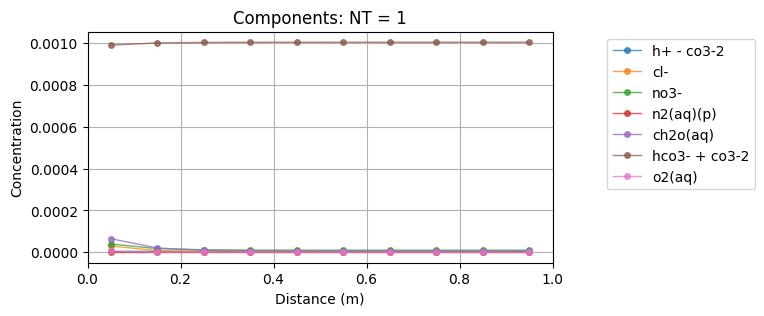

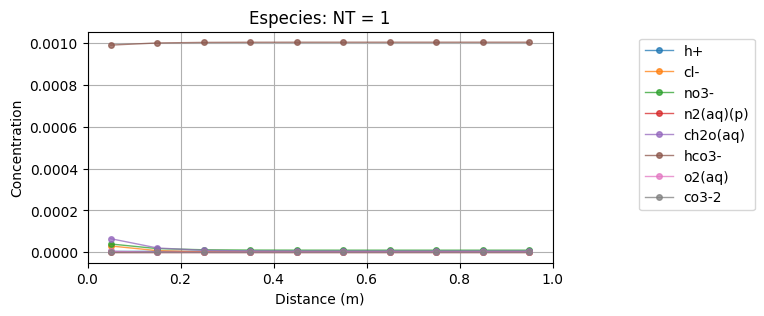

In [8]:
###############################################################
# BLOQUE 8. COMPONENTES Y ESPECIES DESPUES DE REMIX
# Muestra las componentes y especies actualizadas.
###############################################################
plot.show_t(u_new, components["names"], x, y, z, ncol=ncol, delr=delr, yscale="linear", title=f"Components: NT = {NT}")
plot.show_t(s_new, especies["names"], x, y, z, ncol=ncol, delr=delr, yscale="linear", title=f"Especies: NT = {NT}")


<details>
<summary>

## BLOQUE 9. Impresión opcional de resultados finales

</summary>

Esta celda permite inspeccionar numéricamente los resultados finales de la simulación cuando sea necesario.

<details>
<summary><b>Impresión</b></summary>

Contiene instrucciones comentadas para mostrar los arreglos `u_new` y `s_new` sin generar gráficas adicionales.

</details>

</details>

In [9]:
#print(u_new) 
#print(s_new)